In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Input

# Process images and labels
def process_image(image_path):
    image = load_img(image_path, target_size=(224, 224))  # Resize image to 224x224
    image = img_to_array(image) / 255.0  # Convert image to array and normalize
    return image

images_loc = []
labels = []

# Define the directories
forest_fire_dataset_path = '/kaggle/input/forest-fire-image-dataset/FOREST_FIRE_DATASET'
fire_dir = os.path.join(forest_fire_dataset_path, 'FIRE')
non_fire_dir = os.path.join(forest_fire_dataset_path, 'NON_FIRE')

# Check and process images in FIRE directory
if os.path.exists(fire_dir):
    for i in os.listdir(fire_dir):
        images_loc.append(process_image(os.path.join(fire_dir, i)))
        labels.append(0)
else:
    print(f"Directory {fire_dir} does not exist.")

# Check and process images in NON_FIRE directory
if os.path.exists(non_fire_dir):
    for i in os.listdir(non_fire_dir):
        images_loc.append(process_image(os.path.join(non_fire_dir, i)))
        labels.append(1)
else:
    print(f"Directory {non_fire_dir} does not exist.")

print(f"Processed {len(images_loc)} images.")


Processed 11034 images.


In [2]:
from sklearn.model_selection import train_test_split
import shutil
import os

# Paths to FIRE and NON_FIRE directories
fire_dir = '/kaggle/input/forest-fire-image-dataset/FOREST_FIRE_DATASET/FIRE'
non_fire_dir = '/kaggle/input/forest-fire-image-dataset/FOREST_FIRE_DATASET/NON_FIRE'

# Temporary directories for train and test splits
train_dir = '/kaggle/working/Train_Data'
test_dir = '/kaggle/working/Test_Data'

# Create necessary directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(os.path.join(train_dir, 'FIRE'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'NON_FIRE'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'FIRE'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'NON_FIRE'), exist_ok=True)

# Function to split and copy files
def split_dataset(source_dir, train_dest, test_dest, split_ratio=0.6):
    files = os.listdir(source_dir)
    train_files, test_files = train_test_split(files, test_size=1-split_ratio, random_state=42)
    for file in train_files:
        shutil.copy(os.path.join(source_dir, file), os.path.join(train_dest, file))
    for file in test_files:
        shutil.copy(os.path.join(source_dir, file), os.path.join(test_dest, file))

# Split the datasets for FIRE and NON_FIRE
split_dataset(fire_dir, os.path.join(train_dir, 'FIRE'), os.path.join(test_dir, 'FIRE'))
split_dataset(non_fire_dir, os.path.join(train_dir, 'NON_FIRE'), os.path.join(test_dir, 'NON_FIRE'))


**MobileNetV2**

In [3]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Input

# Paths for train and test data
train_dir = '/kaggle/working/Train_Data'
test_dir = '/kaggle/working/Test_Data'

# Define ImageDataGenerators for train and test
datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load MobileNetV2 model without the top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add a custom head for feature extraction
input_layer = Input(shape=(224, 224, 3))
x = base_model(input_layer, training=False)
x = Flatten()(x)
feature_extractor = Model(inputs=input_layer, outputs=x)

# Extract features for training data
train_features = feature_extractor.predict(train_generator)
train_labels = train_generator.classes

# Extract features for test data
test_features = feature_extractor.predict(test_generator)
test_labels = test_generator.classes

# Save the extracted features
np.save('/kaggle/working/train_features_mobilenetv2.npy', train_features)
np.save('/kaggle/working/train_labels_mobilenetv2.npy', train_labels)
np.save('/kaggle/working/test_features_mobilenetv2.npy', test_features)
np.save('/kaggle/working/test_labels_mobilenetv2.npy', test_labels)


Found 6619 images belonging to 2 classes.
Found 4413 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


207/207 ━━━━━━━━━━━━━━━━━━━━ 49s 207ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 208ms/step


MobilnetV2+XGboost

XGBoost Test Accuracy: 97.01%


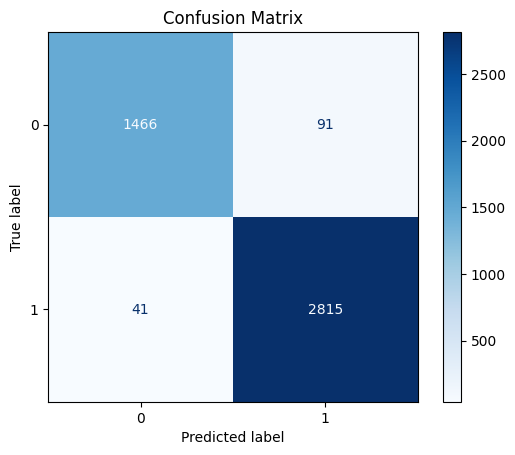

Accuracy: 97.01%
Precision: 96.87%
Recall: 98.56%
F1 Score: 97.71%


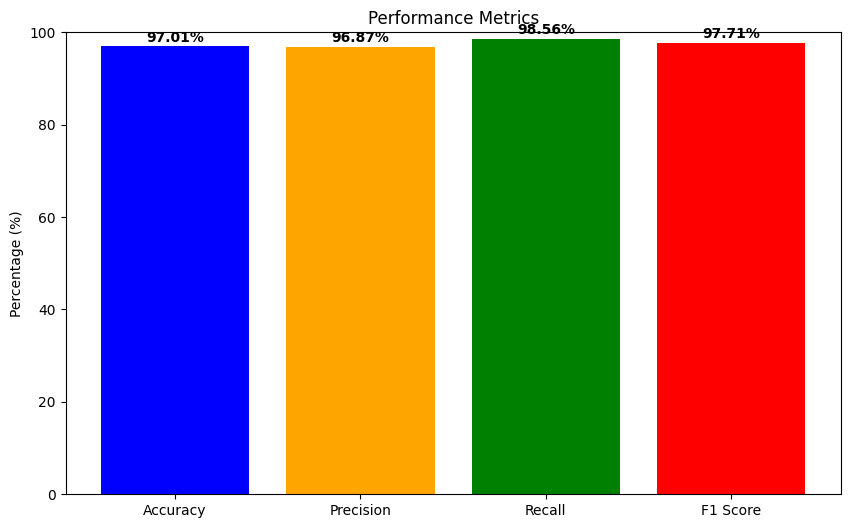

In [4]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_mobilenetv2.npy')
train_labels = np.load('/kaggle/working/train_labels_mobilenetv2.npy')
test_features = np.load('/kaggle/working/test_features_mobilenetv2.npy')
test_labels = np.load('/kaggle/working/test_labels_mobilenetv2.npy')

# Initialize and train the XGBoost classifier
xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_xgb = xgb_classifier.predict(test_features)

# Calculate accuracy
accuracy_xgb = accuracy_score(test_labels, test_predictions_xgb)
print(f"XGBoost Test Accuracy: {accuracy_xgb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


MobileNetV2+Logisticgregartion

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Test Accuracy: 97.46%


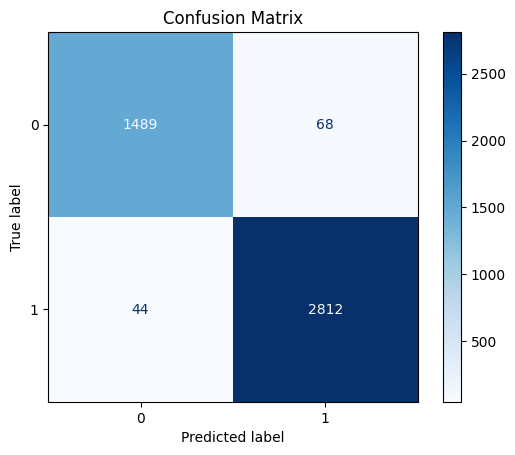

Accuracy: 97.46%
Precision: 97.64%
Recall: 98.46%
F1 Score: 98.05%


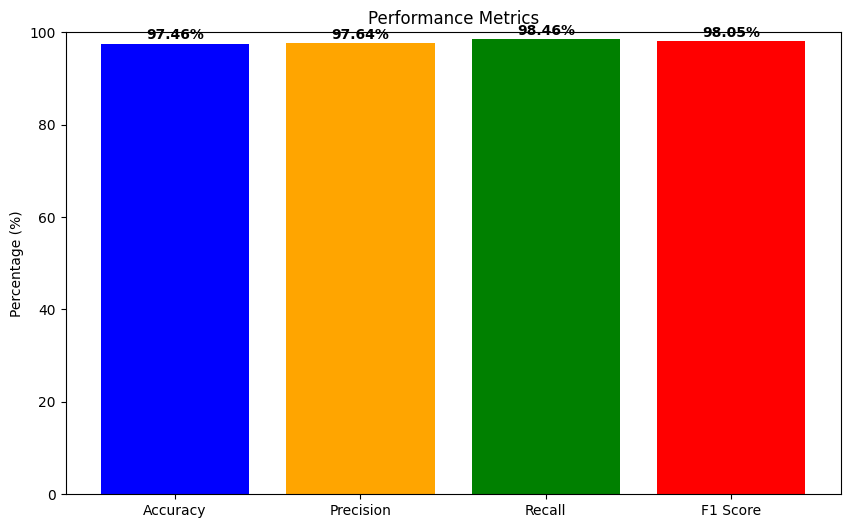

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_mobilenetv2.npy')
train_labels = np.load('/kaggle/working/train_labels_mobilenetv2.npy')
test_features = np.load('/kaggle/working/test_features_mobilenetv2.npy')
test_labels = np.load('/kaggle/working/test_labels_mobilenetv2.npy')

# Initialize and train the Logistic Regression classifier
lr_classifier = LogisticRegression(random_state=42)
lr_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_lr = lr_classifier.predict(test_features)

# Calculate accuracy
accuracy_lr = accuracy_score(test_labels, test_predictions_lr)
print(f"Logistic Regression Test Accuracy: {accuracy_lr * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_lr)
recall = recall_score(test_labels, test_predictions_lr)
f1 = f1_score(test_labels, test_predictions_lr)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Mobilnetv2+naiv boyes

Naive Bayes Test Accuracy: 84.12%


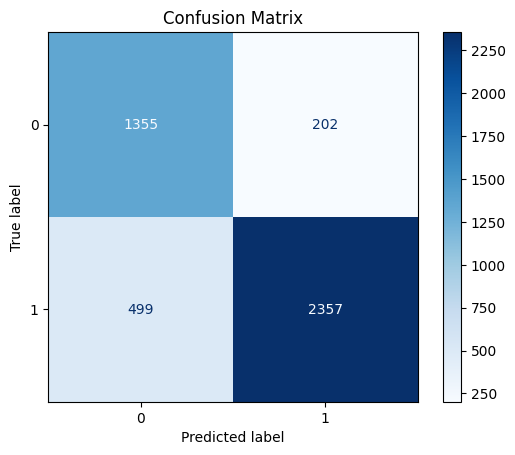

Accuracy: 84.12%
Precision: 92.11%
Recall: 82.53%
F1 Score: 87.05%


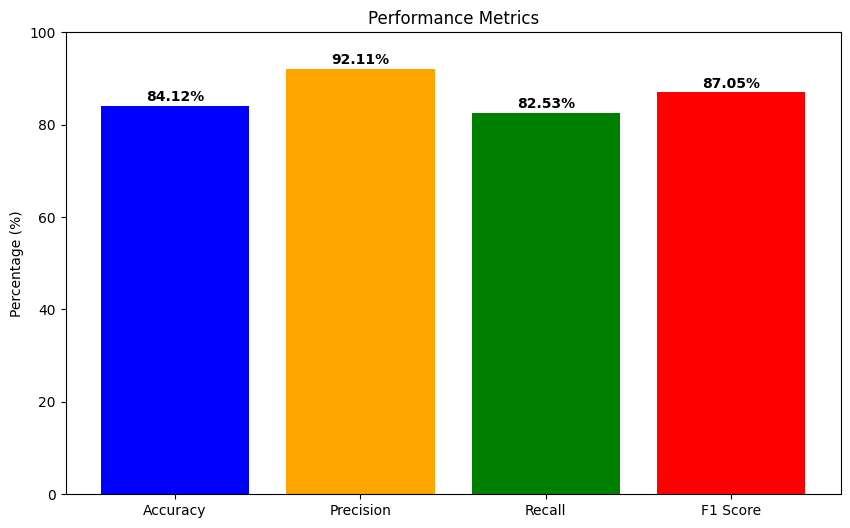

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_mobilenetv2.npy')
train_labels = np.load('/kaggle/working/train_labels_mobilenetv2.npy')
test_features = np.load('/kaggle/working/test_features_mobilenetv2.npy')
test_labels = np.load('/kaggle/working/test_labels_mobilenetv2.npy')

# Initialize and train the Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_nb = nb_classifier.predict(test_features)

# Calculate accuracy
accuracy_nb = accuracy_score(test_labels, test_predictions_nb)
print(f"Naive Bayes Test Accuracy: {accuracy_nb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_nb)
recall = recall_score(test_labels, test_predictions_nb)
f1 = f1_score(test_labels, test_predictions_nb)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


MobileNetV2+Decistion tree

Decision Tree Test Accuracy: 86.47%


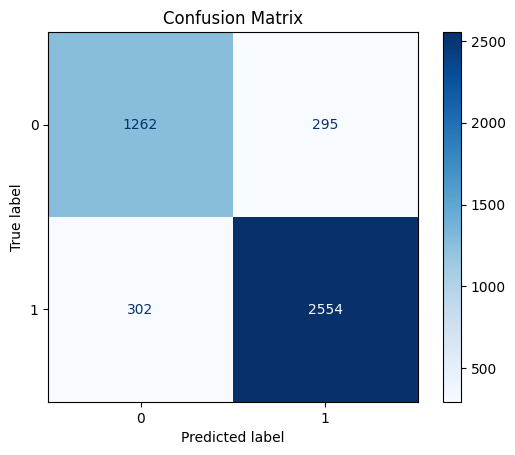

Accuracy: 86.47%
Precision: 89.65%
Recall: 89.43%
F1 Score: 89.54%


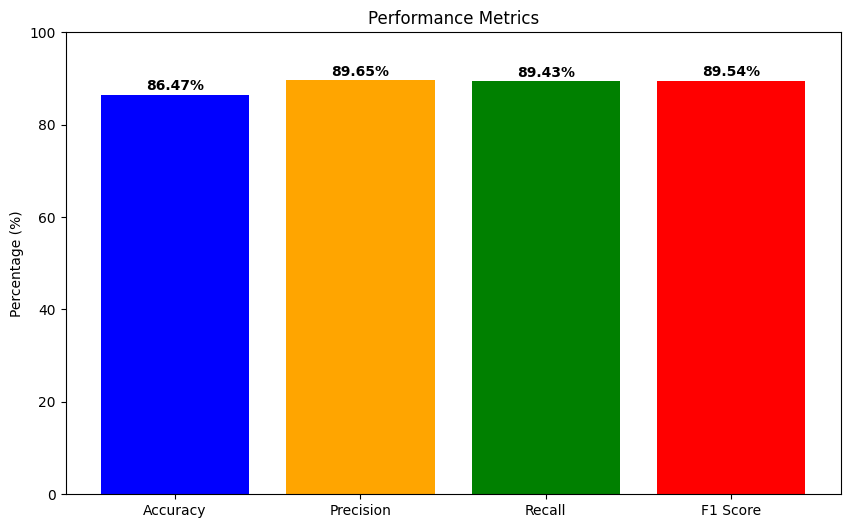

In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_mobilenetv2.npy')
train_labels = np.load('/kaggle/working/train_labels_mobilenetv2.npy')
test_features = np.load('/kaggle/working/test_features_mobilenetv2.npy')
test_labels = np.load('/kaggle/working/test_labels_mobilenetv2.npy')

# Initialize and train the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_dt = dt_classifier.predict(test_features)

# Calculate accuracy
accuracy_dt = accuracy_score(test_labels, test_predictions_dt)
print(f"Decision Tree Test Accuracy: {accuracy_dt * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_dt)
recall = recall_score(test_labels, test_predictions_dt)
f1 = f1_score(test_labels, test_predictions_dt)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Mobilnetv2+SVM

SVM Test Accuracy (MobileNetV2): 97.35%


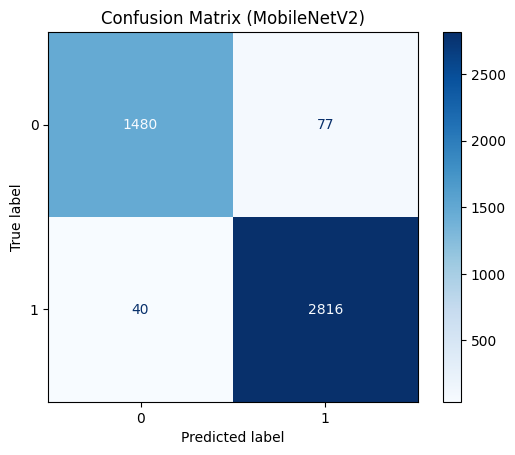

Precision: 97.34%
Recall:    98.60%
F1 Score:  97.96%


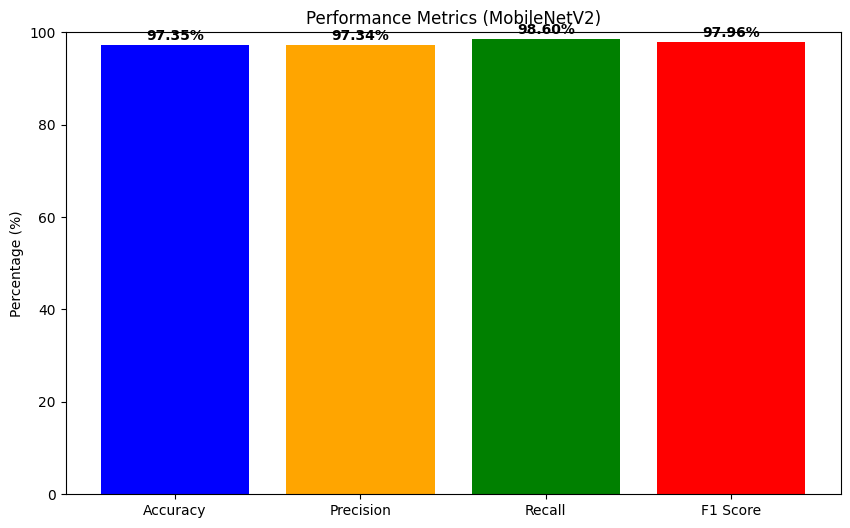

In [5]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load the MobileNetV2 features
train_features = np.load('/kaggle/working/train_features_mobilenetv2.npy')
train_labels   = np.load('/kaggle/working/train_labels_mobilenetv2.npy')
test_features  = np.load('/kaggle/working/test_features_mobilenetv2.npy')
test_labels    = np.load('/kaggle/working/test_labels_mobilenetv2.npy')

# Train the SVM (linear kernel)
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(train_features, train_labels)

# Predict and evaluate
preds = svm_classifier.predict(test_features)
acc = accuracy_score(test_labels, preds)
print(f"SVM Test Accuracy (MobileNetV2): {acc * 100:.2f}%")

# Confusion matrix
cm = confusion_matrix(test_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (MobileNetV2)')
plt.show()

# Compute metrics
precision = precision_score(test_labels, preds)
recall    = recall_score(test_labels, preds)
f1        = f1_score(test_labels, preds)

print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1 Score:  {f1 * 100:.2f}%")

# Plot all four metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [acc * 100, precision * 100, recall * 100, f1 * 100]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics (MobileNetV2)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1,
             f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Randomforest+MobilnetV2

Random Forest Test Accuracy: 95.49%


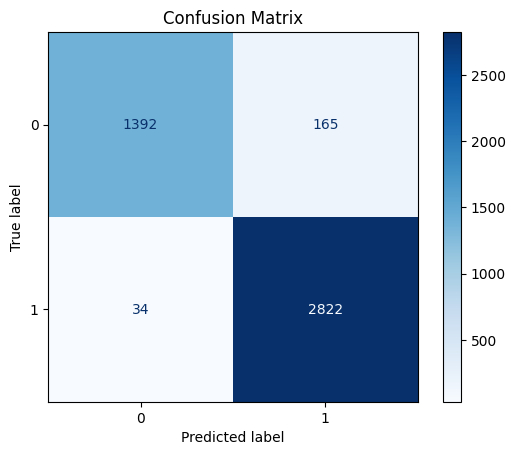

Accuracy: 95.49%
Precision: 94.48%
Recall: 98.81%
F1 Score: 96.59%


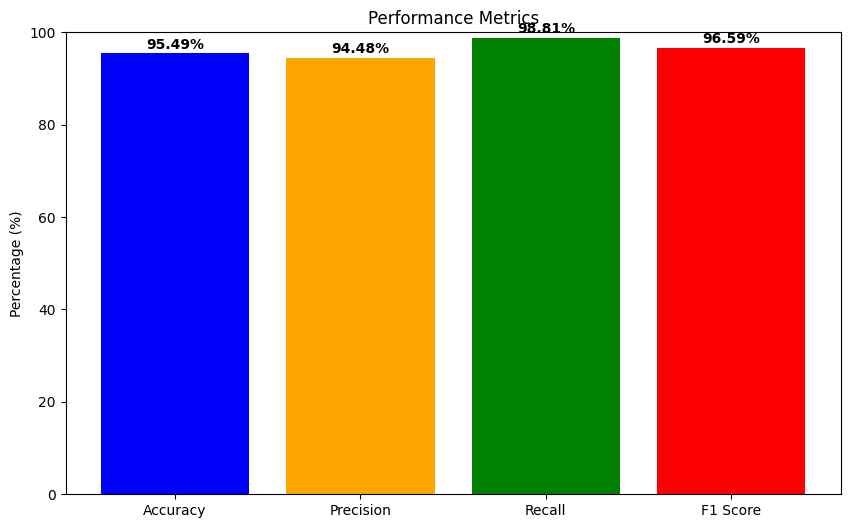

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_mobilenetv2.npy')
train_labels = np.load('/kaggle/working/train_labels_mobilenetv2.npy')
test_features = np.load('/kaggle/working/test_features_mobilenetv2.npy')
test_labels = np.load('/kaggle/working/test_labels_mobilenetv2.npy')

# Initialize and train the Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_rf = rf_classifier.predict(test_features)

# Calculate accuracy
accuracy_rf = accuracy_score(test_labels, test_predictions_rf)
print(f"Random Forest Test Accuracy: {accuracy_rf * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_rf)
recall = recall_score(test_labels, test_predictions_rf)
f1 = f1_score(test_labels, test_predictions_rf)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


**EfficentnetB5**

In [4]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Input

# Paths for train and test data
train_dir = '/kaggle/working/Train_Data'
test_dir = '/kaggle/working/Test_Data'

# Define ImageDataGenerators for train and test
datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load EfficientNetB5 model without the top layer
base_model = EfficientNetB5(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add a custom head for feature extraction
input_layer = Input(shape=(224, 224, 3))
x = base_model(input_layer, training=False)
x = Flatten()(x)
feature_extractor = Model(inputs=input_layer, outputs=x)

# Extract features for training data
train_features = feature_extractor.predict(train_generator)
train_labels = train_generator.classes

# Extract features for test data
test_features = feature_extractor.predict(test_generator)
test_labels = test_generator.classes

# Save the extracted features
np.save('/kaggle/working/train_features_efficientnetb5.npy', train_features)
np.save('/kaggle/working/train_labels_efficientnetb5.npy', train_labels)
np.save('/kaggle/working/test_features_efficientnetb5.npy', test_features)
np.save('/kaggle/working/test_labels_efficientnetb5.npy', test_labels)


Found 6619 images belonging to 2 classes.
Found 4413 images belonging to 2 classes.
207/207 ━━━━━━━━━━━━━━━━━━━━ 65s 259ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 38s 278ms/step


EfficentB5+LogisticRegrestion

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Test Accuracy: 79.56%


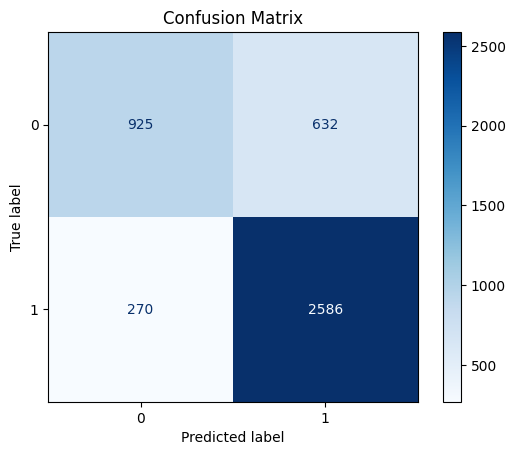

Accuracy: 79.56%
Precision: 80.36%
Recall: 90.55%
F1 Score: 85.15%


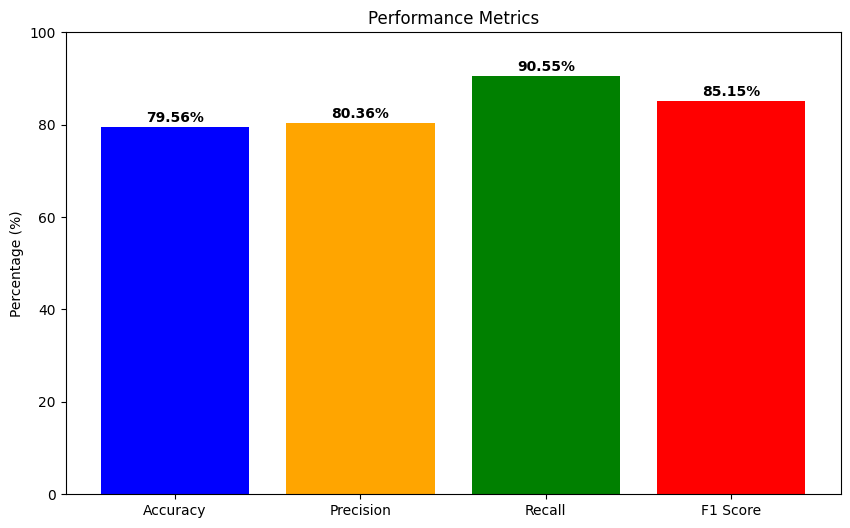

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_efficientnetb5.npy')
train_labels = np.load('/kaggle/working/train_labels_efficientnetb5.npy')
test_features = np.load('/kaggle/working/test_features_efficientnetb5.npy')
test_labels = np.load('/kaggle/working/test_labels_efficientnetb5.npy')

# Initialize and train the Logistic Regression classifier
lr_classifier = LogisticRegression(random_state=42)
lr_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_lr = lr_classifier.predict(test_features)

# Calculate accuracy
accuracy_lr = accuracy_score(test_labels, test_predictions_lr)
print(f"Logistic Regression Test Accuracy: {accuracy_lr * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_lr)
recall = recall_score(test_labels, test_predictions_lr)
f1 = f1_score(test_labels, test_predictions_lr)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


EfficentB5+Naiv Boyes

Naive Bayes Test Accuracy: 45.37%


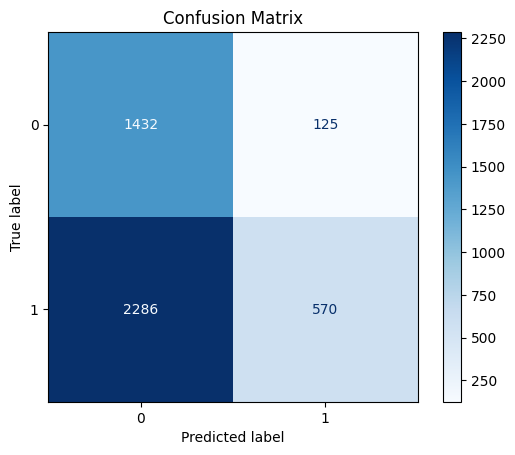

Accuracy: 45.37%
Precision: 82.01%
Recall: 19.96%
F1 Score: 32.10%


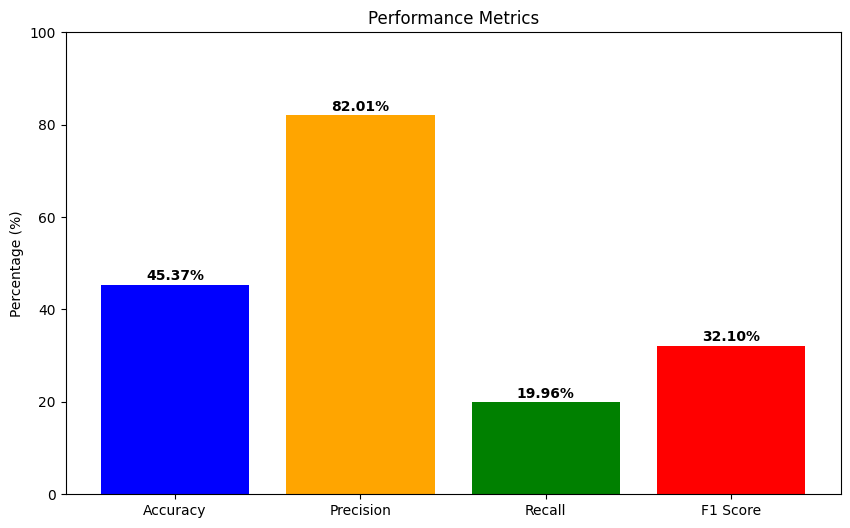

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_efficientnetb5.npy')
train_labels = np.load('/kaggle/working/train_labels_efficientnetb5.npy')
test_features = np.load('/kaggle/working/test_features_efficientnetb5.npy')
test_labels = np.load('/kaggle/working/test_labels_efficientnetb5.npy')

# Initialize and train the Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_nb = nb_classifier.predict(test_features)

# Calculate accuracy
accuracy_nb = accuracy_score(test_labels, test_predictions_nb)
print(f"Naive Bayes Test Accuracy: {accuracy_nb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_nb)
recall = recall_score(test_labels, test_predictions_nb)
f1 = f1_score(test_labels, test_predictions_nb)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


EffiNeB5+ Decstiontree

Decision Tree Test Accuracy: 77.84%


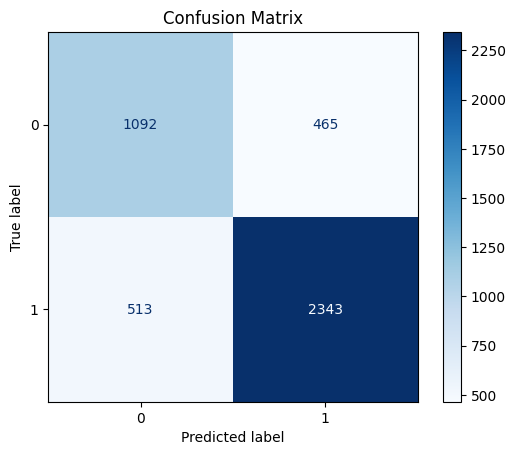

Accuracy: 77.84%
Precision: 83.44%
Recall: 82.04%
F1 Score: 82.73%


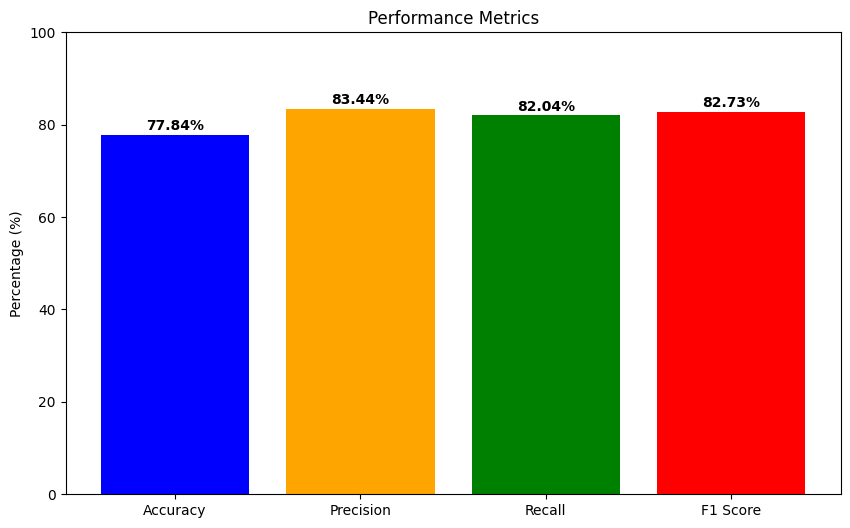

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_efficientnetb5.npy')
train_labels = np.load('/kaggle/working/train_labels_efficientnetb5.npy')
test_features = np.load('/kaggle/working/test_features_efficientnetb5.npy')
test_labels = np.load('/kaggle/working/test_labels_efficientnetb5.npy')

# Initialize and train the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_dt = dt_classifier.predict(test_features)

# Calculate accuracy
accuracy_dt = accuracy_score(test_labels, test_predictions_dt)
print(f"Decision Tree Test Accuracy: {accuracy_dt * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_dt)
recall = recall_score(test_labels, test_predictions_dt)
f1 = f1_score(test_labels, test_predictions_dt)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


EfficentB5+SVM

SVM Test Accuracy: 82.69%


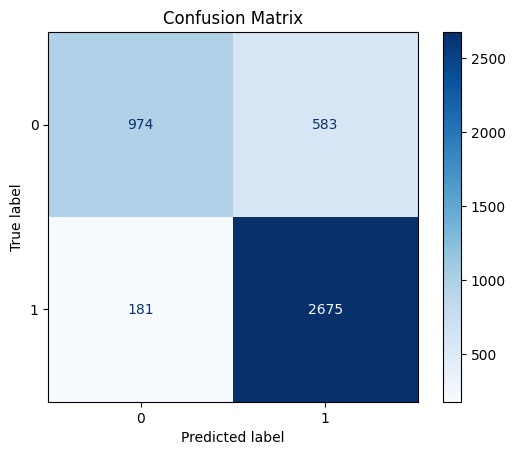

Accuracy: 82.69%
Precision: 82.11%
Recall: 93.66%
F1 Score: 87.50%


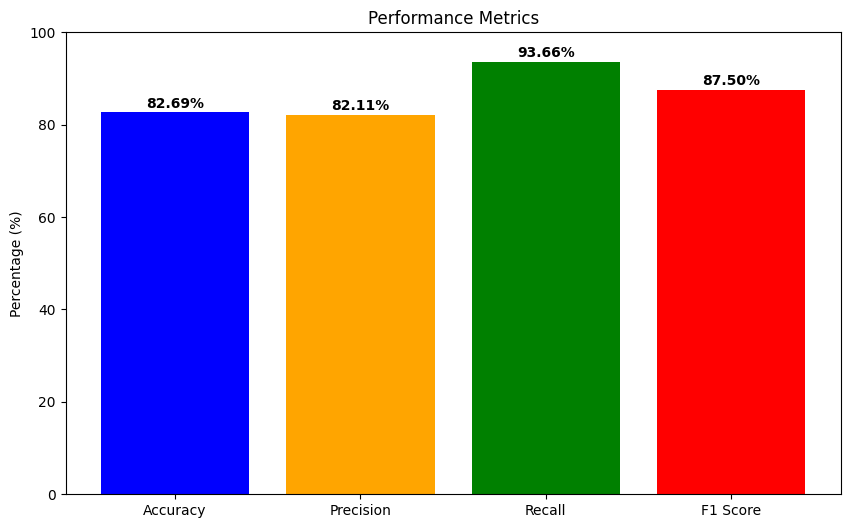

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_efficientnetb5.npy')
train_labels = np.load('/kaggle/working/train_labels_efficientnetb5.npy')
test_features = np.load('/kaggle/working/test_features_efficientnetb5.npy')
test_labels = np.load('/kaggle/working/test_labels_efficientnetb5.npy')

# Initialize and train the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_svm = svm_classifier.predict(test_features)

# Calculate accuracy
accuracy_svm = accuracy_score(test_labels, test_predictions_svm)
print(f"SVM Test Accuracy: {accuracy_svm * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_svm)
recall = recall_score(test_labels, test_predictions_svm)
f1 = f1_score(test_labels, test_predictions_svm)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


randomforest+EfficententB5

Random Forest Test Accuracy: 86.40%


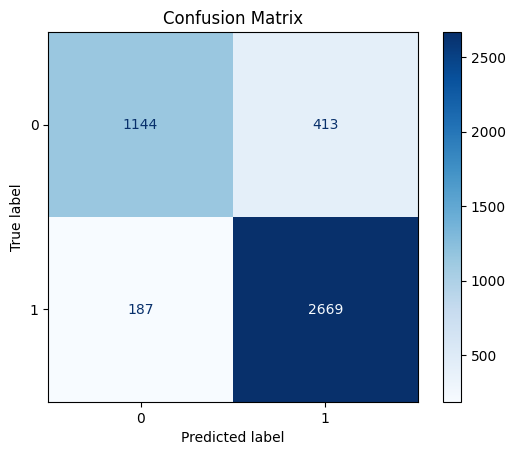

Accuracy: 86.40%
Precision: 86.60%
Recall: 93.45%
F1 Score: 89.90%


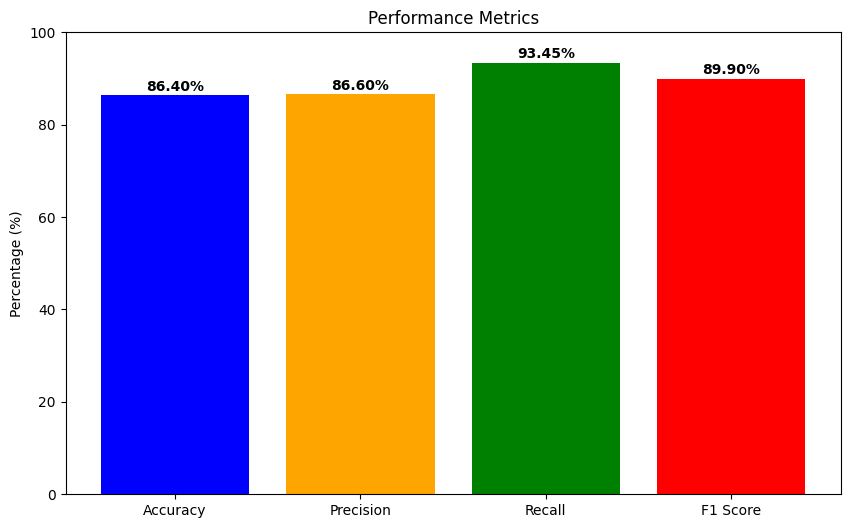

In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_efficientnetb5.npy')
train_labels = np.load('/kaggle/working/train_labels_efficientnetb5.npy')
test_features = np.load('/kaggle/working/test_features_efficientnetb5.npy')
test_labels = np.load('/kaggle/working/test_labels_efficientnetb5.npy')

# Initialize and train the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_rf = rf_classifier.predict(test_features)

# Calculate accuracy
accuracy_rf = accuracy_score(test_labels, test_predictions_rf)
print(f"Random Forest Test Accuracy: {accuracy_rf * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_rf)
recall = recall_score(test_labels, test_predictions_rf)
f1 = f1_score(test_labels, test_predictions_rf)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Xgboost+efficentnetB5

Initial Memory Usage: 14.37 GiB
Memory Usage After Loading Features: 15.20 GiB
Memory Usage After Training: 15.12 GiB
XGBoost Test Accuracy: 88.65%


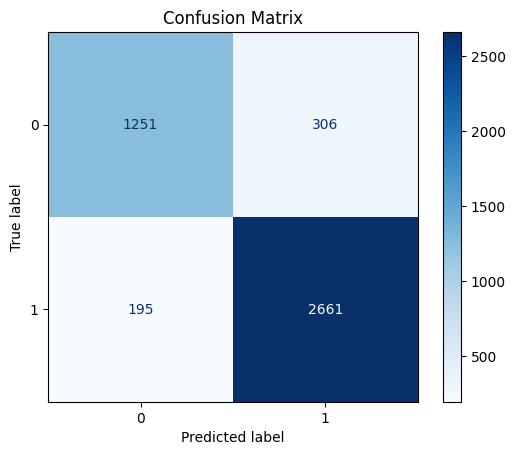

Accuracy: 88.65%
Precision: 89.69%
Recall: 93.17%
F1 Score: 91.40%


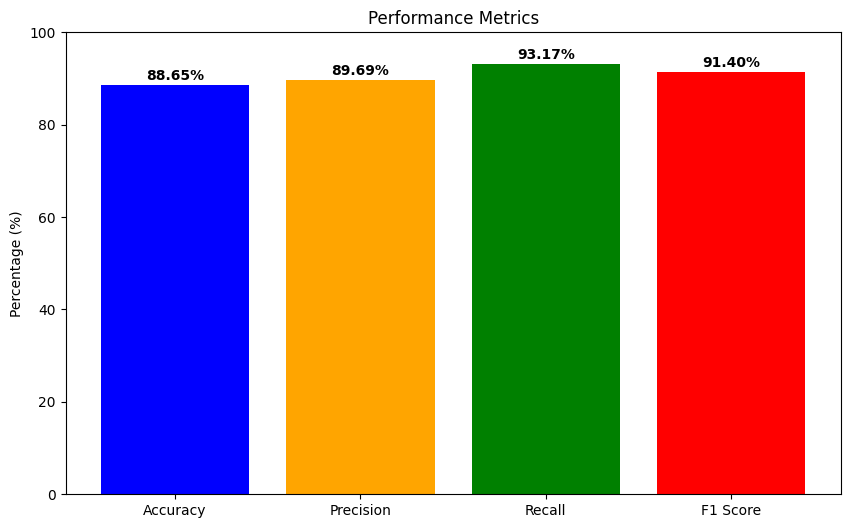

In [2]:
import numpy as np
import psutil
import gc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Function to check memory usage
def check_memory_usage():
    process = psutil.Process()
    mem_info = process.memory_info()
    return mem_info.rss / (1024 ** 3)  # Convert bytes to GiB

# Initial memory usage
print(f"Initial Memory Usage: {check_memory_usage():.2f} GiB")

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_efficientnetb5.npy')
train_labels = np.load('/kaggle/working/train_labels_efficientnetb5.npy')
test_features = np.load('/kaggle/working/test_features_efficientnetb5.npy')
test_labels = np.load('/kaggle/working/test_labels_efficientnetb5.npy')

# Memory usage after loading features
print(f"Memory Usage After Loading Features: {check_memory_usage():.2f} GiB")

# Initialize and train the XGBoost classifier with CPU support and adjusted parameters
xgb_classifier = XGBClassifier(random_state=42, max_depth=4, n_estimators=50, subsample=0.8, colsample_bytree=0.8, tree_method='hist')
xgb_classifier.fit(train_features, train_labels)

# Memory usage after training
print(f"Memory Usage After Training: {check_memory_usage():.2f} GiB")

# Clear unused variables and run garbage collection
del train_features, train_labels
gc.collect()

# Predict on the test set
test_predictions_xgb = xgb_classifier.predict(test_features)

# Calculate accuracy
accuracy_xgb = accuracy_score(test_labels, test_predictions_xgb)
print(f"XGBoost Test Accuracy: {accuracy_xgb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_xgb)
recall = recall_score(test_labels, test_predictions_xgb)
f1 = f1_score(test_labels, test_predictions_xgb)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


**InceptionV3**

In [3]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Input

# Paths for train and test data
train_dir = '/kaggle/working/Train_Data'
test_dir = '/kaggle/working/Test_Data'

# Define ImageDataGenerators for train and test
datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load InceptionV3 model without the top layer
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add a custom head for feature extraction
input_layer = Input(shape=(224, 224, 3))
x = base_model(input_layer, training=False)
x = Flatten()(x)
feature_extractor = Model(inputs=input_layer, outputs=x)

# Extract features for training data
train_features = feature_extractor.predict(train_generator)
train_labels = train_generator.classes

# Extract features for test data
test_features = feature_extractor.predict(test_generator)
test_labels = test_generator.classes

# Save the extracted features
np.save('/kaggle/working/train_features_inceptionv3.npy', train_features)
np.save('/kaggle/working/train_labels_inceptionv3.npy', train_labels)
np.save('/kaggle/working/test_features_inceptionv3.npy', test_features)
np.save('/kaggle/working/test_labels_inceptionv3.npy', test_labels)


Found 6619 images belonging to 2 classes.
Found 4413 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


207/207 ━━━━━━━━━━━━━━━━━━━━ 51s 206ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 28s 204ms/step


InceptionV3+LogisticRegreation

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Test Accuracy: 97.87%


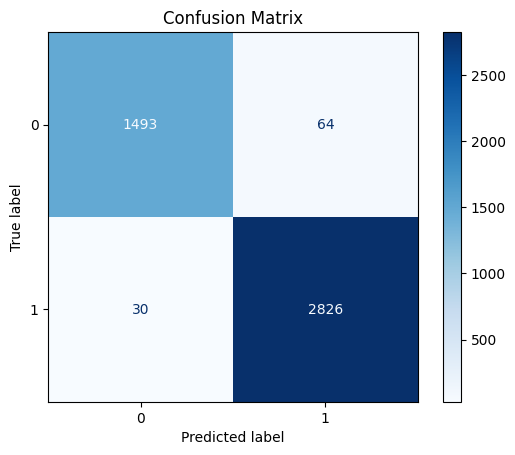

Accuracy: 97.87%
Precision: 97.79%
Recall: 98.95%
F1 Score: 98.36%


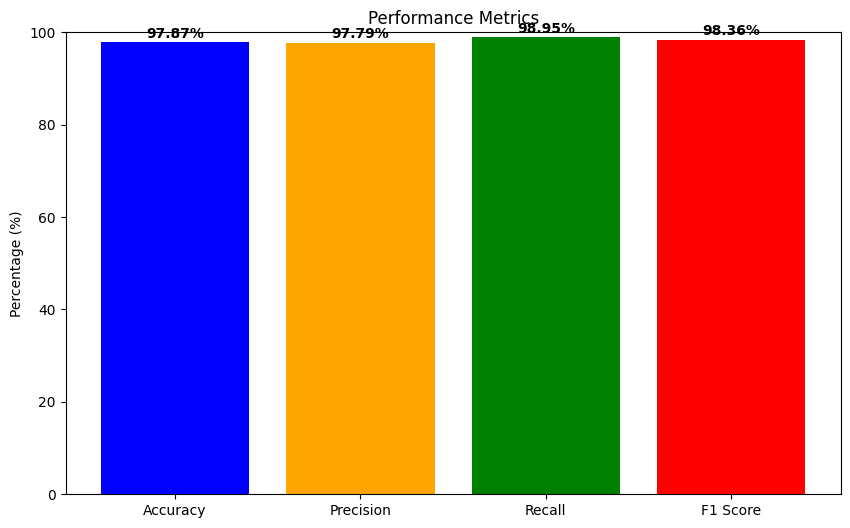

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_inceptionv3.npy')
train_labels = np.load('/kaggle/working/train_labels_inceptionv3.npy')
test_features = np.load('/kaggle/working/test_features_inceptionv3.npy')
test_labels = np.load('/kaggle/working/test_labels_inceptionv3.npy')

# Initialize and train the Logistic Regression classifier
log_reg_classifier = LogisticRegression(random_state=42 )
log_reg_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_log_reg = log_reg_classifier.predict(test_features)

# Calculate accuracy
accuracy_log_reg = accuracy_score(test_labels, test_predictions_log_reg)
print(f"Logistic Regression Test Accuracy: {accuracy_log_reg * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_log_reg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_log_reg)
recall = recall_score(test_labels, test_predictions_log_reg)
f1 = f1_score(test_labels, test_predictions_log_reg)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


InceptionV3+Naiv boyes

Naive Bayes Test Accuracy: 91.25%


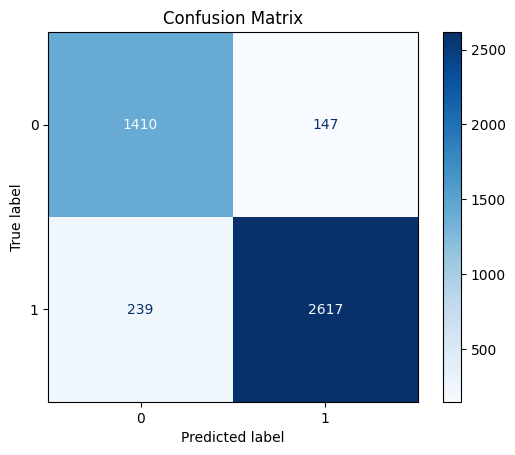

Accuracy: 91.25%
Precision: 94.68%
Recall: 91.63%
F1 Score: 93.13%


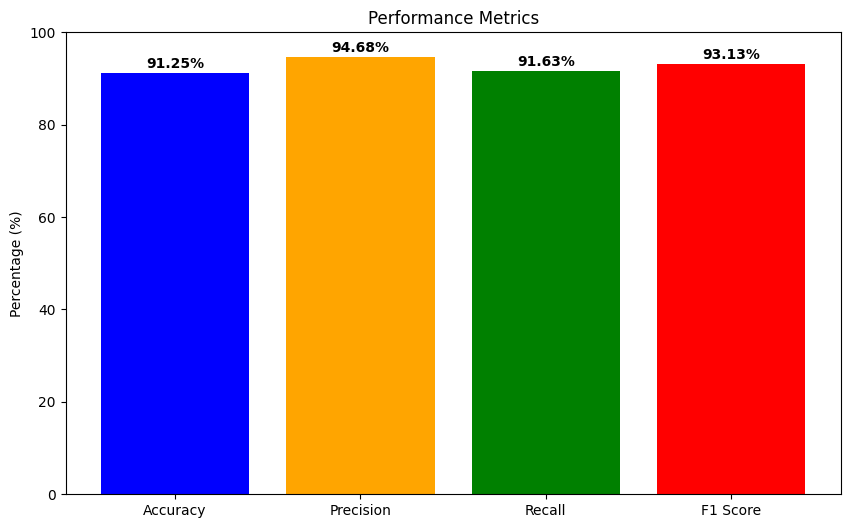

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_inceptionv3.npy')
train_labels = np.load('/kaggle/working/train_labels_inceptionv3.npy')
test_features = np.load('/kaggle/working/test_features_inceptionv3.npy')
test_labels = np.load('/kaggle/working/test_labels_inceptionv3.npy')

# Initialize and train the Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_nb = nb_classifier.predict(test_features)

# Calculate accuracy
accuracy_nb = accuracy_score(test_labels, test_predictions_nb)
print(f"Naive Bayes Test Accuracy: {accuracy_nb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_nb)
recall = recall_score(test_labels, test_predictions_nb)
f1 = f1_score(test_labels, test_predictions_nb)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


InceptionV3+Decisiontree

Decision Tree Test Accuracy: 89.92%


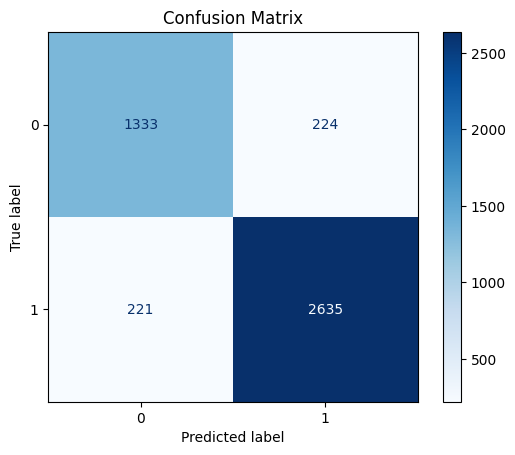

Accuracy: 89.92%
Precision: 92.17%
Recall: 92.26%
F1 Score: 92.21%


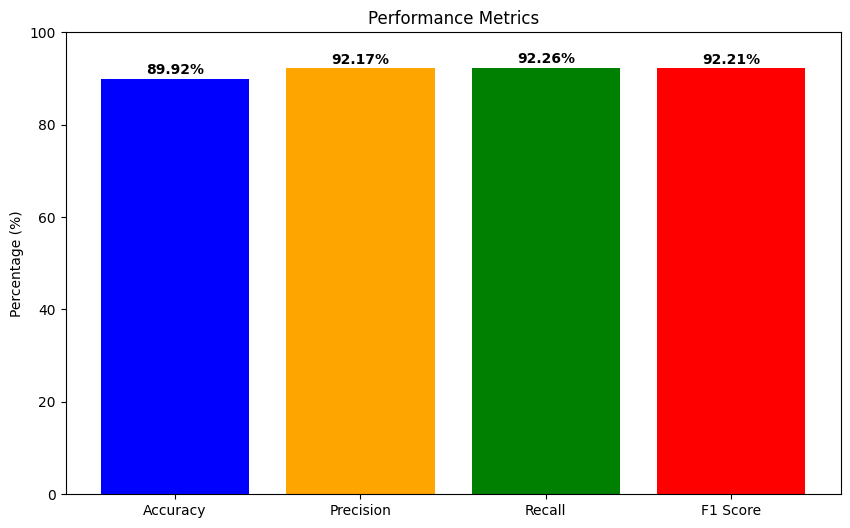

In [4]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_inceptionv3.npy')
train_labels = np.load('/kaggle/working/train_labels_inceptionv3.npy')
test_features = np.load('/kaggle/working/test_features_inceptionv3.npy')
test_labels = np.load('/kaggle/working/test_labels_inceptionv3.npy')

# Initialize and train the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_dt = dt_classifier.predict(test_features)

# Calculate accuracy
accuracy_dt = accuracy_score(test_labels, test_predictions_dt)
print(f"Decision Tree Test Accuracy: {accuracy_dt * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_dt)
recall = recall_score(test_labels, test_predictions_dt)
f1 = f1_score(test_labels, test_predictions_dt)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


InceptionV3+SVM

SVM Test Accuracy: 97.87%


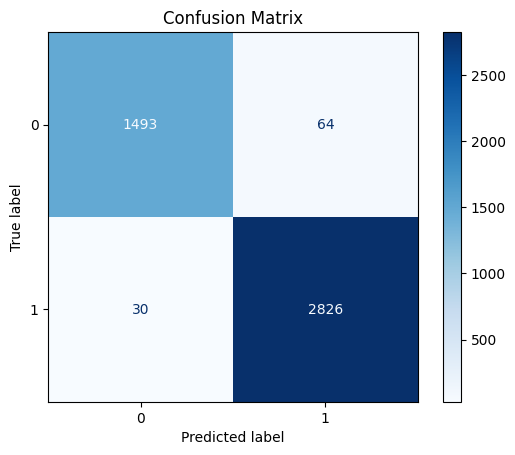

Accuracy: 97.87%
Precision: 97.79%
Recall: 98.95%
F1 Score: 98.36%


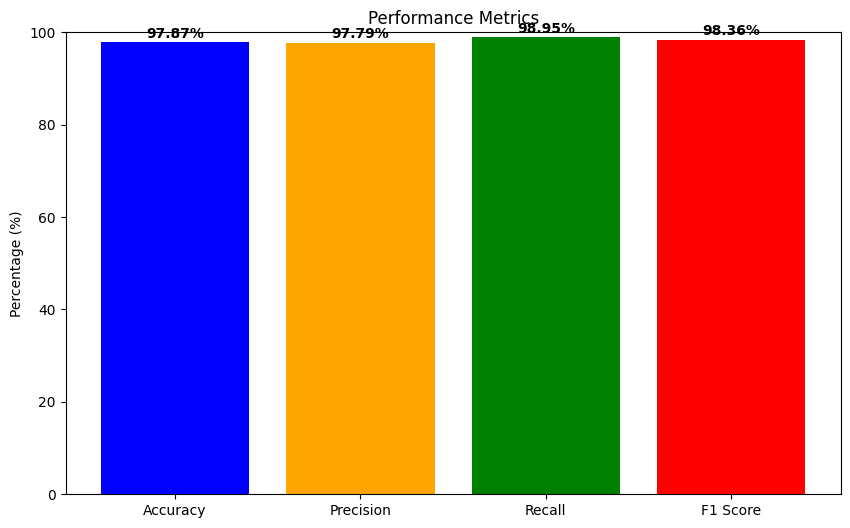

In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_inceptionv3.npy')
train_labels = np.load('/kaggle/working/train_labels_inceptionv3.npy')
test_features = np.load('/kaggle/working/test_features_inceptionv3.npy')
test_labels = np.load('/kaggle/working/test_labels_inceptionv3.npy')

# Initialize and train the SVM classifier with the correct parameter
svm_classifier = SVC(kernel='linear', random_state=42, C=1.0)
svm_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_svm = svm_classifier.predict(test_features)

# Calculate accuracy
accuracy_svm = accuracy_score(test_labels, test_predictions_svm)
print(f"SVM Test Accuracy: {accuracy_svm * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_svm)
recall = recall_score(test_labels, test_predictions_svm)
f1 = f1_score(test_labels, test_predictions_svm)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


InceptionV3+Xgboost

XGBoost Test Accuracy: 97.12%


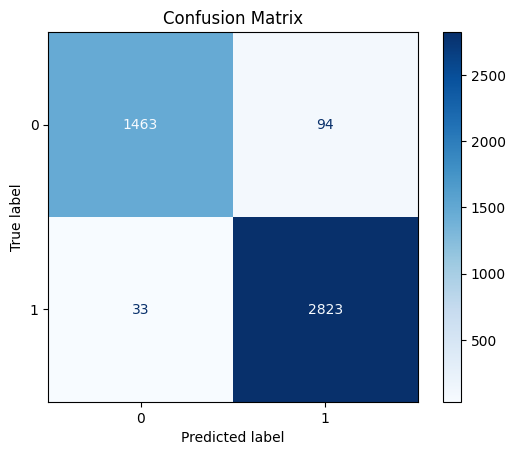

Accuracy: 97.12%
Precision: 96.78%
Recall: 98.84%
F1 Score: 97.80%


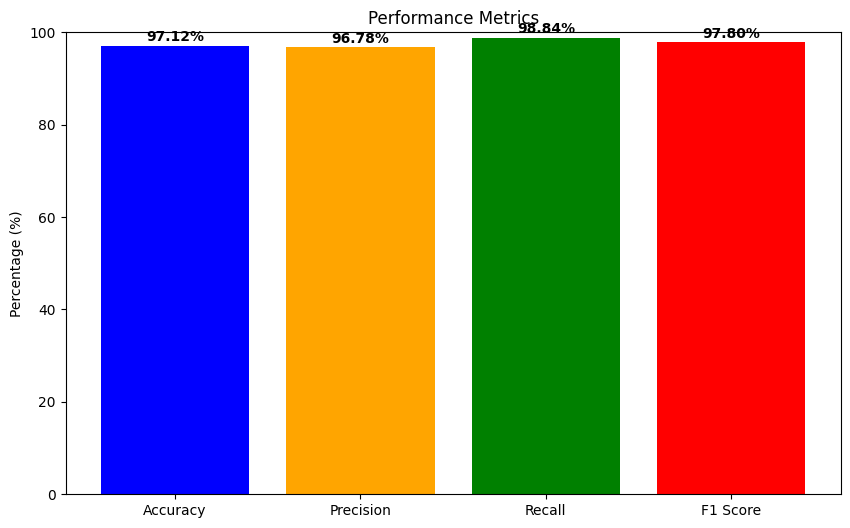

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_inceptionv3.npy')
train_labels = np.load('/kaggle/working/train_labels_inceptionv3.npy')
test_features = np.load('/kaggle/working/test_features_inceptionv3.npy')
test_labels = np.load('/kaggle/working/test_labels_inceptionv3.npy')

# Initialize and train the XGBoost classifier
xgb_classifier = XGBClassifier(random_state=42, max_depth=4, n_estimators=50, subsample=0.8, colsample_bytree=0.8, tree_method='hist')
xgb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_xgb = xgb_classifier.predict(test_features)

# Calculate accuracy
accuracy_xgb = accuracy_score(test_labels, test_predictions_xgb)
print(f"XGBoost Test Accuracy: {accuracy_xgb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_xgb)
recall = recall_score(test_labels, test_predictions_xgb)
f1 = f1_score(test_labels, test_predictions_xgb)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


InceptionV3+randomforest

Random Forest Test Accuracy: 94.72%


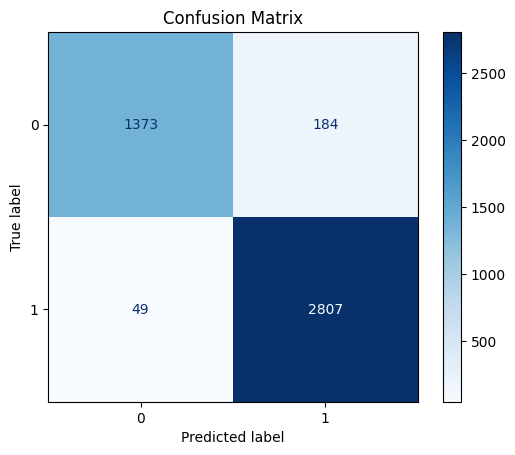

Accuracy: 94.72%
Precision: 93.85%
Recall: 98.28%
F1 Score: 96.02%


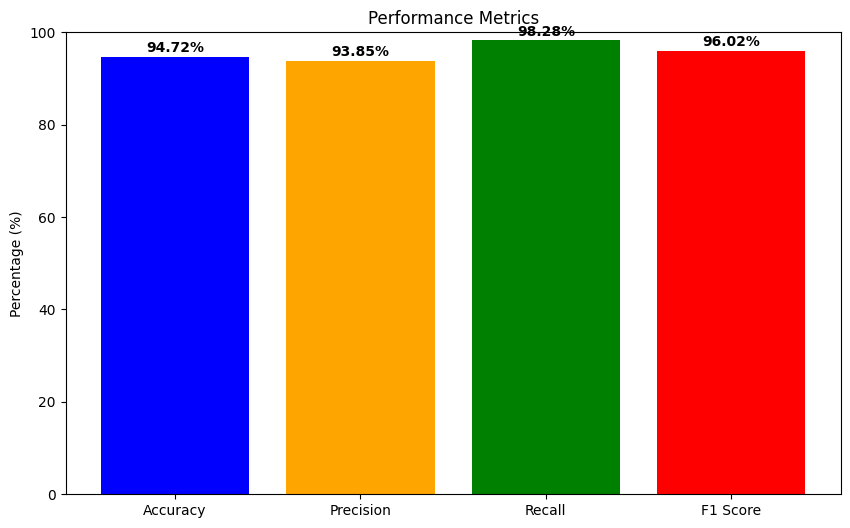

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_inceptionv3.npy')
train_labels = np.load('/kaggle/working/train_labels_inceptionv3.npy')
test_features = np.load('/kaggle/working/test_features_inceptionv3.npy')
test_labels = np.load('/kaggle/working/test_labels_inceptionv3.npy')

# Initialize and train the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_rf = rf_classifier.predict(test_features)

# Calculate accuracy
accuracy_rf = accuracy_score(test_labels, test_predictions_rf)
print(f"Random Forest Test Accuracy: {accuracy_rf * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_rf)
recall = recall_score(test_labels, test_predictions_rf)
f1 = f1_score(test_labels, test_predictions_rf)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


**VGG-19**

In [14]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Input

# Paths for train and test data
train_dir = '/kaggle/working/Train_Data'
test_dir = '/kaggle/working/Test_Data'

# Define ImageDataGenerators for train and test
datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load VGG19 model without the top layer
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add a custom head for feature extraction
input_layer = Input(shape=(224, 224, 3))
x = base_model(input_layer, training=False)
x = Flatten()(x)
feature_extractor = Model(inputs=input_layer, outputs=x)

# Extract features for training data
train_features = feature_extractor.predict(train_generator)
train_labels = train_generator.classes

# Extract features for test data
test_features = feature_extractor.predict(test_generator)
test_labels = test_generator.classes

# Save the extracted features
np.save('/kaggle/working/train_features_vgg19.npy', train_features)
np.save('/kaggle/working/train_labels_vgg19.npy', train_labels)
np.save('/kaggle/working/test_features_vgg19.npy', test_features)
np.save('/kaggle/working/test_labels_vgg19.npy', test_labels)


Found 6619 images belonging to 2 classes.
Found 4413 images belonging to 2 classes.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


207/207 ━━━━━━━━━━━━━━━━━━━━ 54s 226ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 35s 254ms/step


VGG-19+xgboost

XGBoost Test Accuracy: 93.77%


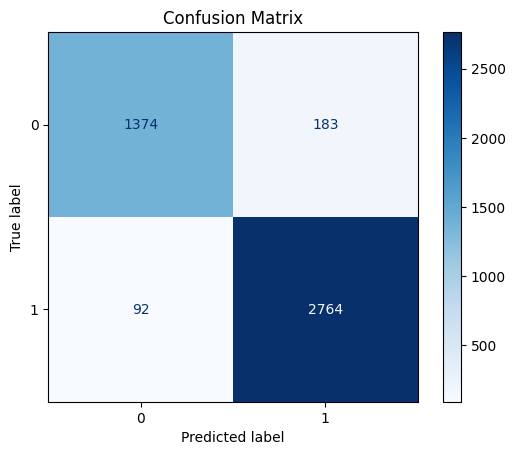

Accuracy: 93.77%
Precision: 93.79%
Recall: 96.78%
F1 Score: 95.26%


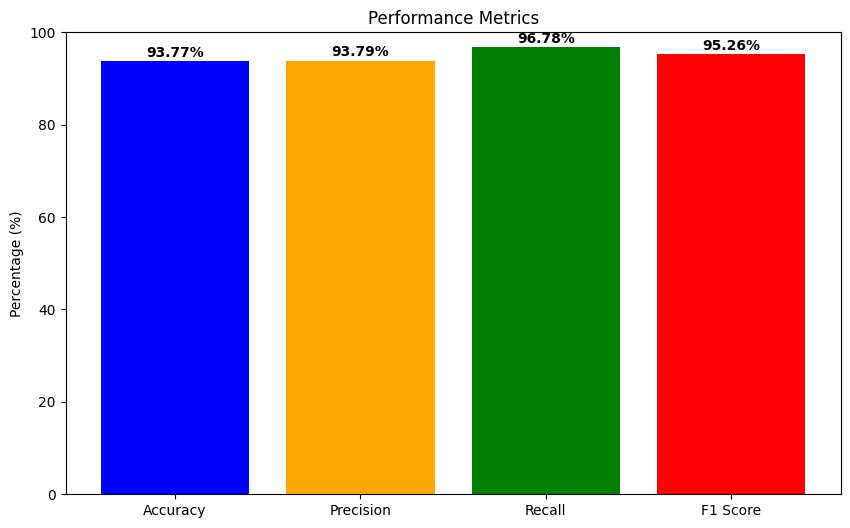

In [4]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_vgg19.npy')
train_labels = np.load('/kaggle/working/train_labels_vgg19.npy')
test_features = np.load('/kaggle/working/test_features_vgg19.npy')
test_labels = np.load('/kaggle/working/test_labels_vgg19.npy')

# Initialize and train the XGBoost classifier
xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_xgb = xgb_classifier.predict(test_features)

# Calculate accuracy
accuracy_xgb = accuracy_score(test_labels, test_predictions_xgb)
print(f"XGBoost Test Accuracy: {accuracy_xgb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Vgg-19+SVM

SVM Test Accuracy: 93.93%


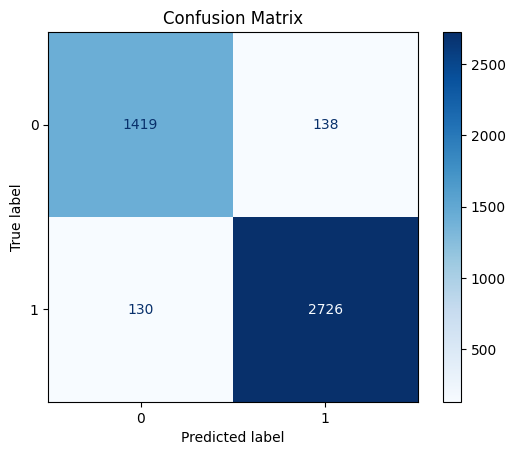

Accuracy: 93.93%
Precision: 95.18%
Recall: 95.45%
F1 Score: 95.31%


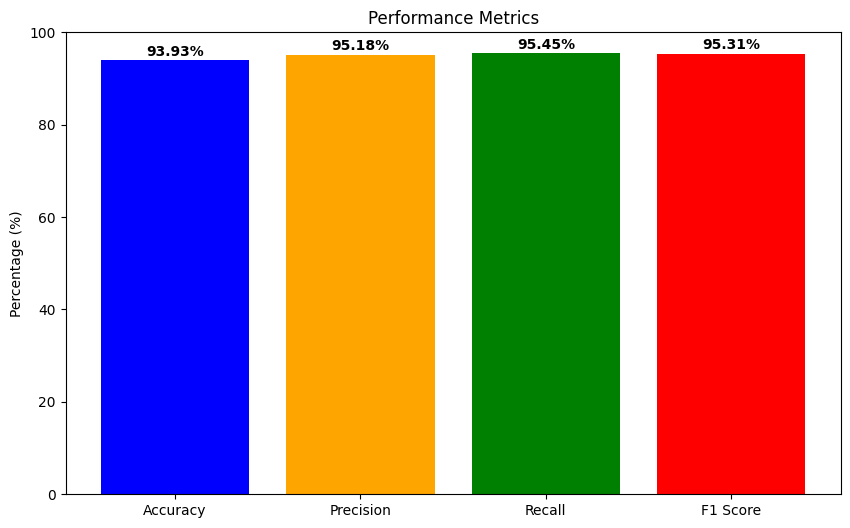

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_vgg19.npy')
train_labels = np.load('/kaggle/working/train_labels_vgg19.npy')
test_features = np.load('/kaggle/working/test_features_vgg19.npy')
test_labels = np.load('/kaggle/working/test_labels_vgg19.npy')

# Initialize and train the SVM classifier with the correct parameter
svm_classifier = SVC(kernel='linear', random_state=42, C=1.0)
svm_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_svm = svm_classifier.predict(test_features)

# Calculate accuracy
accuracy_svm = accuracy_score(test_labels, test_predictions_svm)
print(f"SVM Test Accuracy: {accuracy_svm * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_svm)
recall = recall_score(test_labels, test_predictions_svm)
f1 = f1_score(test_labels, test_predictions_svm)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


VGG-19+randomforest

Random Forest Test Accuracy: 90.64%


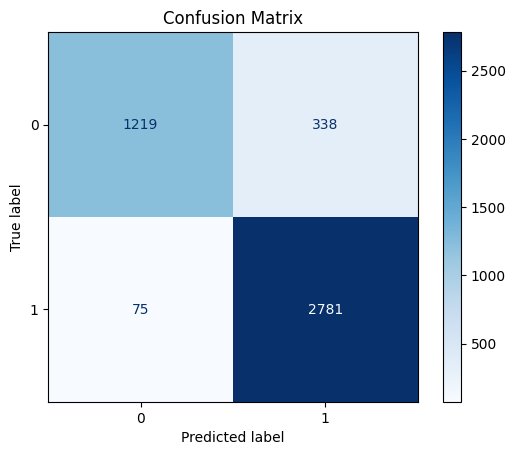

Accuracy: 90.64%
Precision: 89.16%
Recall: 97.37%
F1 Score: 93.09%


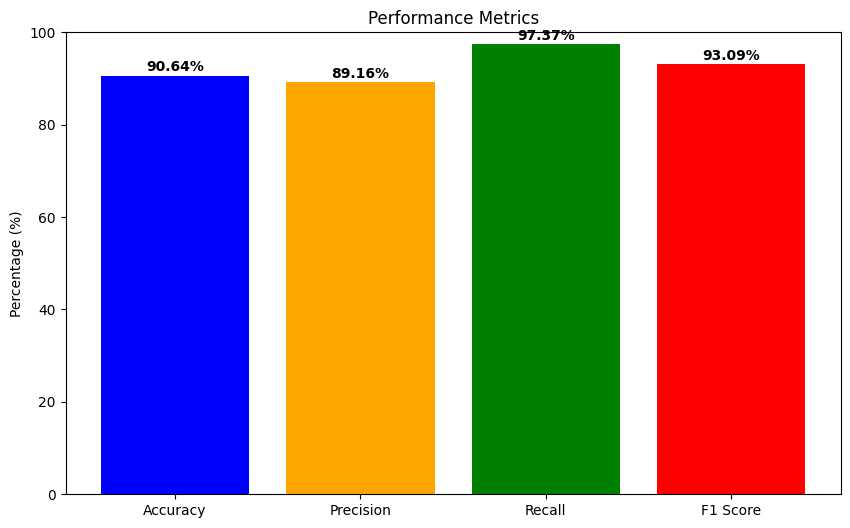

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_vgg19.npy')
train_labels = np.load('/kaggle/working/train_labels_vgg19.npy')
test_features = np.load('/kaggle/working/test_features_vgg19.npy')
test_labels = np.load('/kaggle/working/test_labels_vgg19.npy')

# Initialize and train the Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_rf = rf_classifier.predict(test_features)

# Calculate accuracy
accuracy_rf = accuracy_score(test_labels, test_predictions_rf)
print(f"Random Forest Test Accuracy: {accuracy_rf * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_rf)
recall = recall_score(test_labels, test_predictions_rf)
f1 = f1_score(test_labels, test_predictions_rf)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Vgg-19+Logisticregration

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Test Accuracy: 94.38%


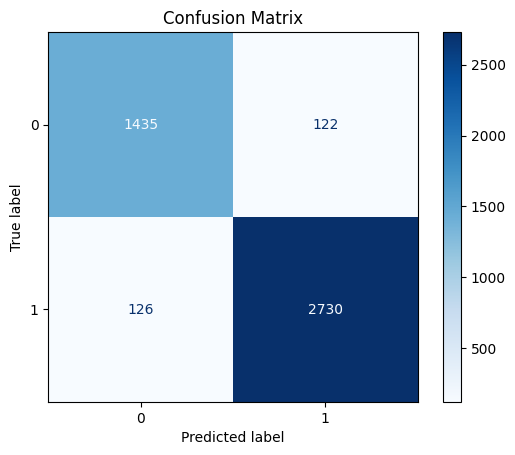

Accuracy: 94.38%
Precision: 95.72%
Recall: 95.59%
F1 Score: 95.66%


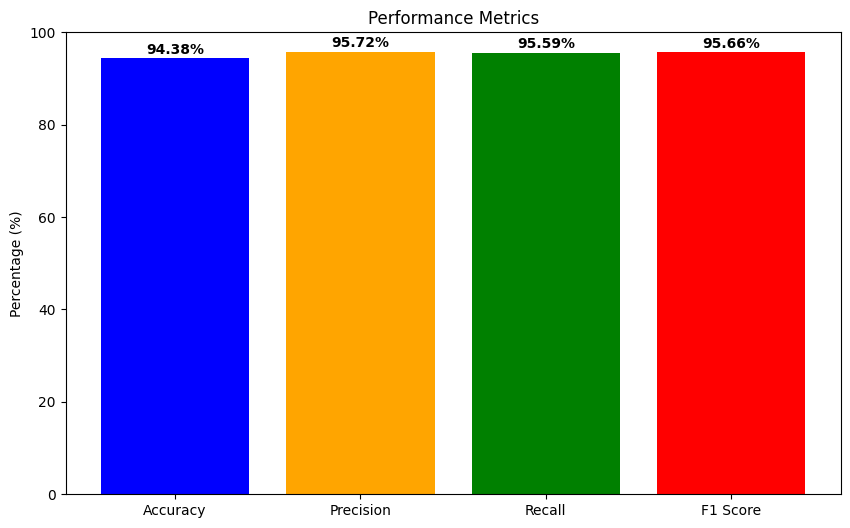

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_vgg19.npy')
train_labels = np.load('/kaggle/working/train_labels_vgg19.npy')
test_features = np.load('/kaggle/working/test_features_vgg19.npy')
test_labels = np.load('/kaggle/working/test_labels_vgg19.npy')

# Initialize and train the Logistic Regression classifier with the C parameter
log_reg_classifier = LogisticRegression(random_state=42, C=1.0)
log_reg_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_log_reg = log_reg_classifier.predict(test_features)

# Calculate accuracy
accuracy_log_reg = accuracy_score(test_labels, test_predictions_log_reg)
print(f"Logistic Regression Test Accuracy: {accuracy_log_reg * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_log_reg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_log_reg)
recall = recall_score(test_labels, test_predictions_log_reg)
f1 = f1_score(test_labels, test_predictions_log_reg)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Vgg19+naiv boyes

Naive Bayes Test Accuracy: 63.20%


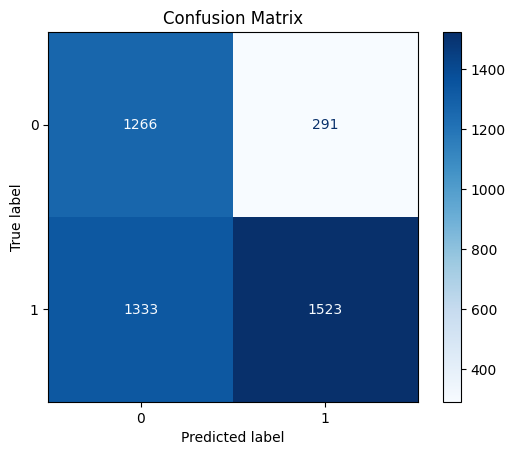

Accuracy: 63.20%
Precision: 83.96%
Recall: 53.33%
F1 Score: 65.22%


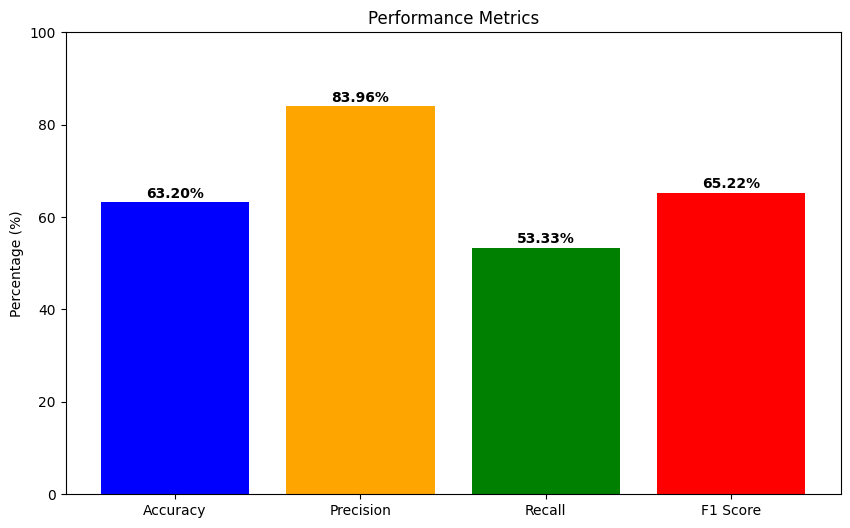

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_vgg19.npy')
train_labels = np.load('/kaggle/working/train_labels_vgg19.npy')
test_features = np.load('/kaggle/working/test_features_vgg19.npy')
test_labels = np.load('/kaggle/working/test_labels_vgg19.npy')

# Initialize and train the Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_nb = nb_classifier.predict(test_features)

# Calculate accuracy
accuracy_nb = accuracy_score(test_labels, test_predictions_nb)
print(f"Naive Bayes Test Accuracy: {accuracy_nb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_nb)
recall = recall_score(test_labels, test_predictions_nb)
f1 = f1_score(test_labels, test_predictions_nb)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Vgg19+decistion tree

Decision Tree Test Accuracy: 80.67%


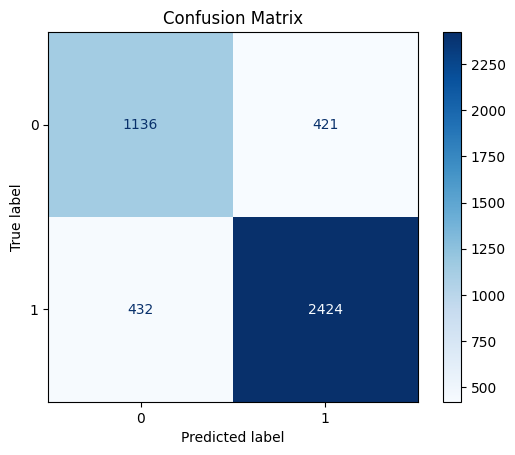

Accuracy: 80.67%
Precision: 85.20%
Recall: 84.87%
F1 Score: 85.04%


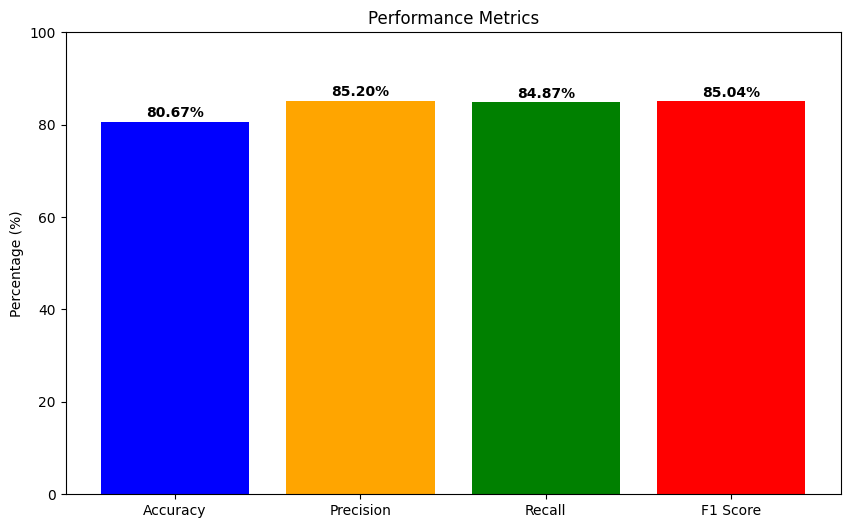

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_vgg19.npy')
train_labels = np.load('/kaggle/working/train_labels_vgg19.npy')
test_features = np.load('/kaggle/working/test_features_vgg19.npy')
test_labels = np.load('/kaggle/working/test_labels_vgg19.npy')

# Initialize and train the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_dt = dt_classifier.predict(test_features)

# Calculate accuracy
accuracy_dt = accuracy_score(test_labels, test_predictions_dt)
print(f"Decision Tree Test Accuracy: {accuracy_dt * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_dt)
recall = recall_score(test_labels, test_predictions_dt)
f1 = f1_score(test_labels, test_predictions_dt)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Xception

In [19]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Input

# Paths for train and test data
train_dir = '/kaggle/working/Train_Data'
test_dir = '/kaggle/working/Test_Data'

# Define ImageDataGenerators for train and test
datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Load Xception model without the top layer
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add a custom head for feature extraction
input_layer = Input(shape=(224, 224, 3))
x = base_model(input_layer, training=False)
x = Flatten()(x)
feature_extractor = Model(inputs=input_layer, outputs=x)

# Extract features for training data
train_features = feature_extractor.predict(train_generator)
train_labels = train_generator.classes

# Extract features for test data
test_features = feature_extractor.predict(test_generator)
test_labels = test_generator.classes

# Save the extracted features
np.save('/kaggle/working/train_features_xception.npy', train_features)
np.save('/kaggle/working/train_labels_xception.npy', train_labels)
np.save('/kaggle/working/test_features_xception.npy', test_features)
np.save('/kaggle/working/test_labels_xception.npy', test_labels)


Found 6619 images belonging to 2 classes.
Found 4413 images belonging to 2 classes.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


207/207 ━━━━━━━━━━━━━━━━━━━━ 52s 225ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 31s 225ms/step


Xception+SVM

SVM Test Accuracy: 97.42%


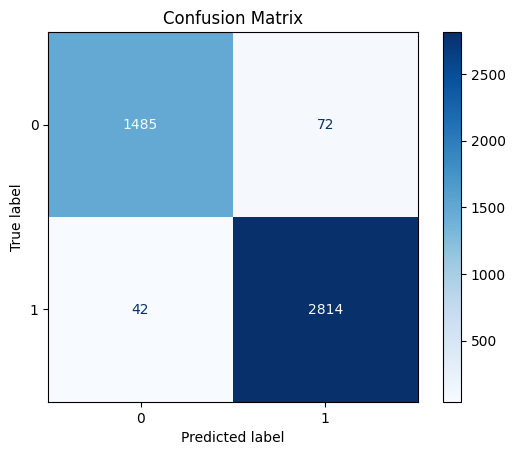

Accuracy: 97.42%
Precision: 97.51%
Recall: 98.53%
F1 Score: 98.01%


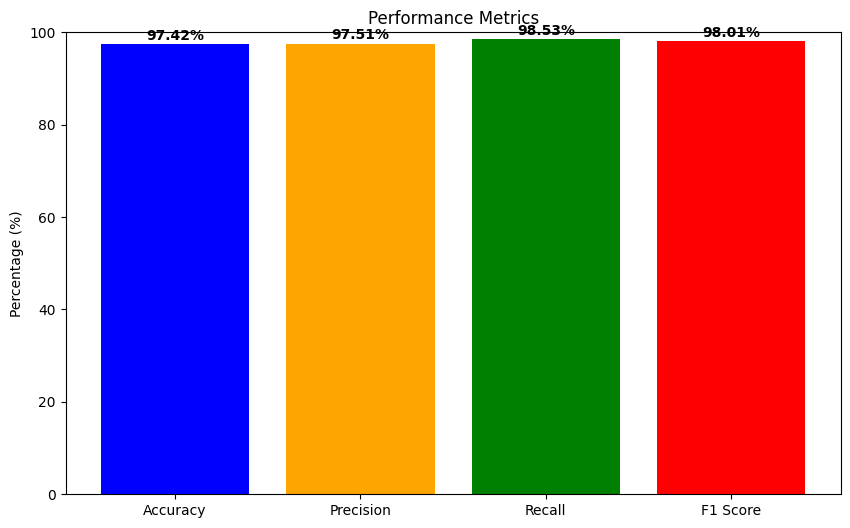

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_xception.npy')
train_labels = np.load('/kaggle/working/train_labels_xception.npy')
test_features = np.load('/kaggle/working/test_features_xception.npy')
test_labels = np.load('/kaggle/working/test_labels_xception.npy')

# Initialize and train the SVM classifier with the correct parameter
svm_classifier = SVC(kernel='linear', random_state=42, C=1.0)
svm_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_svm = svm_classifier.predict(test_features)

# Calculate accuracy
accuracy_svm = accuracy_score(test_labels, test_predictions_svm)
print(f"SVM Test Accuracy: {accuracy_svm * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_svm)
recall = recall_score(test_labels, test_predictions_svm)
f1 = f1_score(test_labels, test_predictions_svm)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Xception+Decstiontree

Decision Tree Test Accuracy: 90.75%


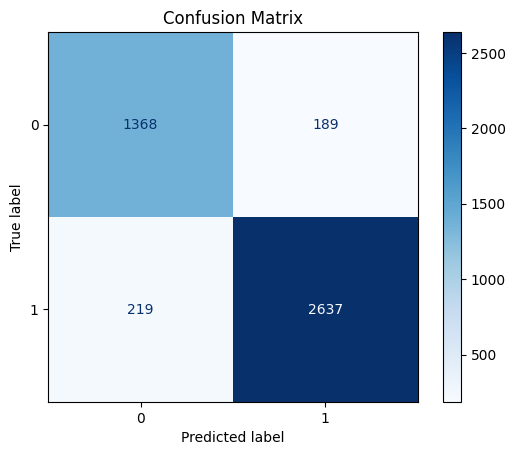

Accuracy: 90.75%
Precision: 93.31%
Recall: 92.33%
F1 Score: 92.82%


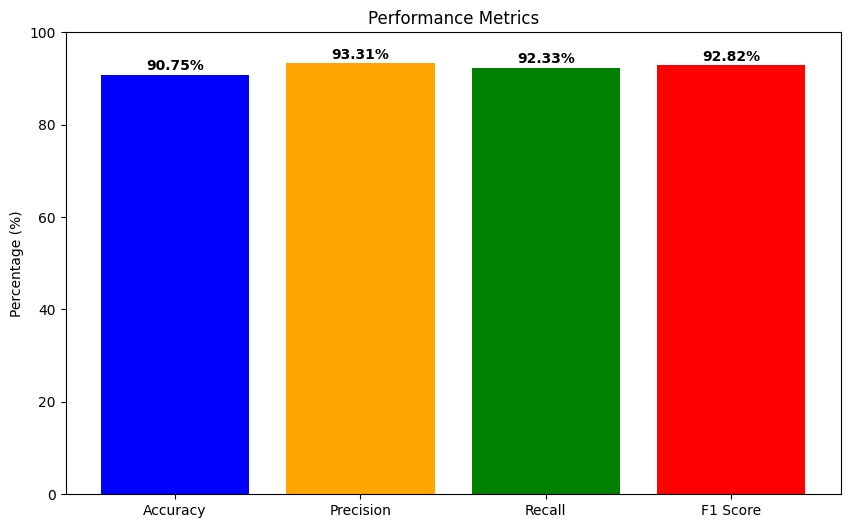

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_xception.npy')
train_labels = np.load('/kaggle/working/train_labels_xception.npy')
test_features = np.load('/kaggle/working/test_features_xception.npy')
test_labels = np.load('/kaggle/working/test_labels_xception.npy')

# Initialize and train the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_dt = dt_classifier.predict(test_features)

# Calculate accuracy
accuracy_dt = accuracy_score(test_labels, test_predictions_dt)
print(f"Decision Tree Test Accuracy: {accuracy_dt * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_dt)
recall = recall_score(test_labels, test_predictions_dt)
f1 = f1_score(test_labels, test_predictions_dt)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Xception+Randomforest

Random Forest Test Accuracy: 95.94%


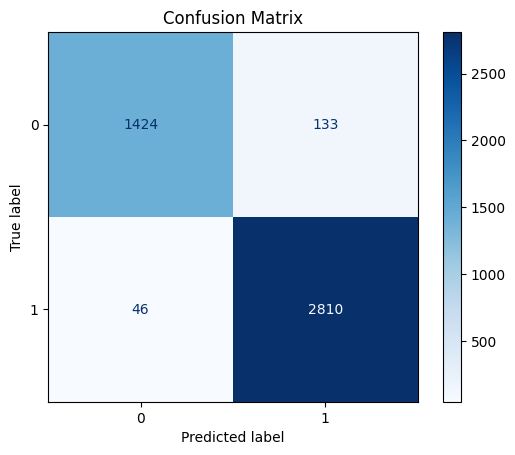

Accuracy: 95.94%
Precision: 95.48%
Recall: 98.39%
F1 Score: 96.91%


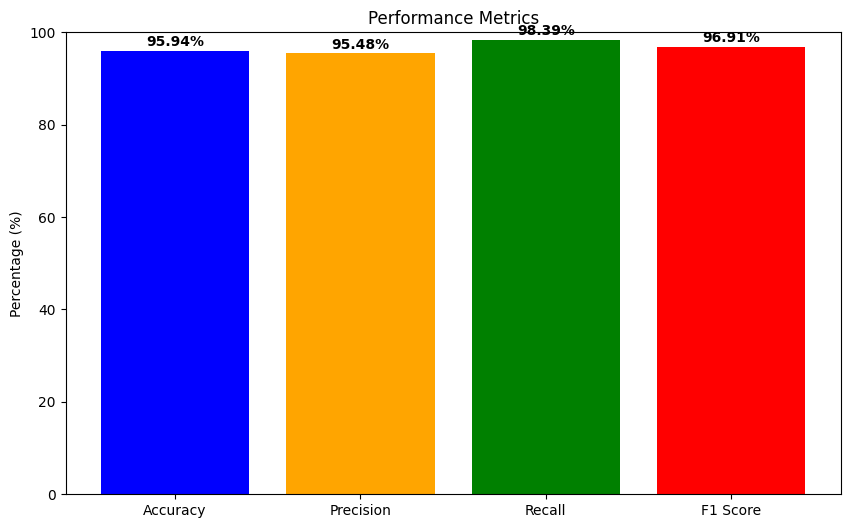

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_xception.npy')
train_labels = np.load('/kaggle/working/train_labels_xception.npy')
test_features = np.load('/kaggle/working/test_features_xception.npy')
test_labels = np.load('/kaggle/working/test_labels_xception.npy')

# Initialize and train the Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_rf = rf_classifier.predict(test_features)

# Calculate accuracy
accuracy_rf = accuracy_score(test_labels, test_predictions_rf)
print(f"Random Forest Test Accuracy: {accuracy_rf * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_rf)
recall = recall_score(test_labels, test_predictions_rf)
f1 = f1_score(test_labels, test_predictions_rf)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()


Xception+naiv boyes

Naive Bayes Test Accuracy: 80.04%


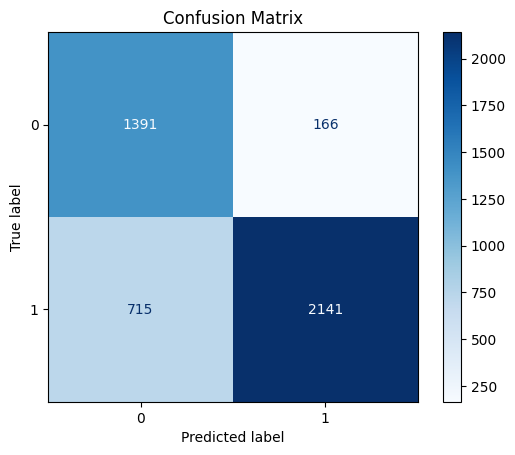

Accuracy: 80.04%
Precision: 92.80%
Recall: 74.96%
F1 Score: 82.94%


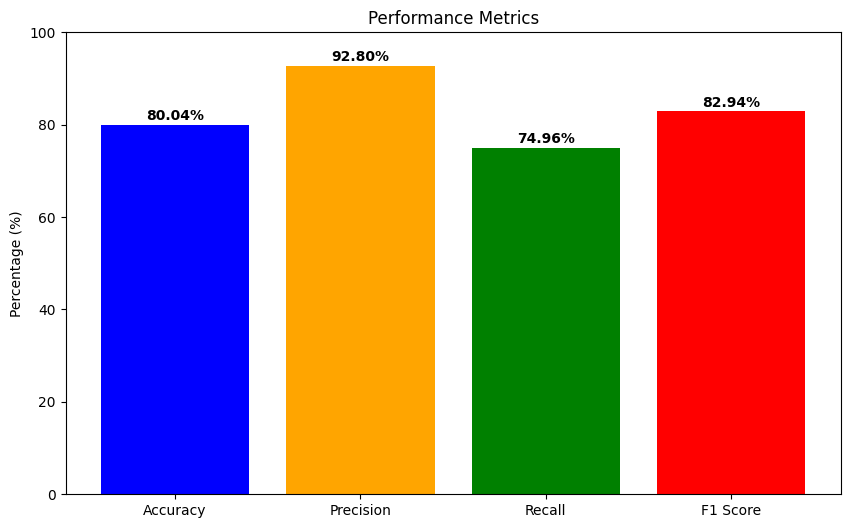

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

# Load the extracted features
train_features = np.load('/kaggle/working/train_features_xception.npy')
train_labels = np.load('/kaggle/working/train_labels_xception.npy')
test_features = np.load('/kaggle/working/test_features_xception.npy')
test_labels = np.load('/kaggle/working/test_labels_xception.npy')

# Initialize and train the Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(train_features, train_labels)

# Predict on the test set
test_predictions_nb = nb_classifier.predict(test_features)

# Calculate accuracy
accuracy_nb = accuracy_score(test_labels, test_predictions_nb)
print(f"Naive Bayes Test Accuracy: {accuracy_nb * 100:.2f}%")

# Generate and plot the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Extract values from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate performance metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = precision_score(test_labels, test_predictions_nb)
recall = recall_score(test_labels, test_predictions_nb)
f1 = f1_score(test_labels, test_predictions_nb)

# Print the metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Prepare the data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Plot the metrics
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title('Performance Metrics')

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.show()
